# 1. Imports and visualization settings

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
from src.io import build_accelerations
from src.io import build_metadata
from src.cleaning_signals import preprocess_signals_single, preprocess_signals_aggregated
from src.cleaning_metadata import clean_metadata
from src.plot_settings import set_plot_style
colors = set_plot_style()

# 2. Data loading

In [3]:
zip_path = Path("..") / "data" / "raw" / "query.zip"
df_acc = build_accelerations(zip_path)
df_meta = build_metadata(zip_path)
df_meta_clean = clean_metadata(df_meta)

# 3. Signals Exploration

## 3.1 Signal length distribution

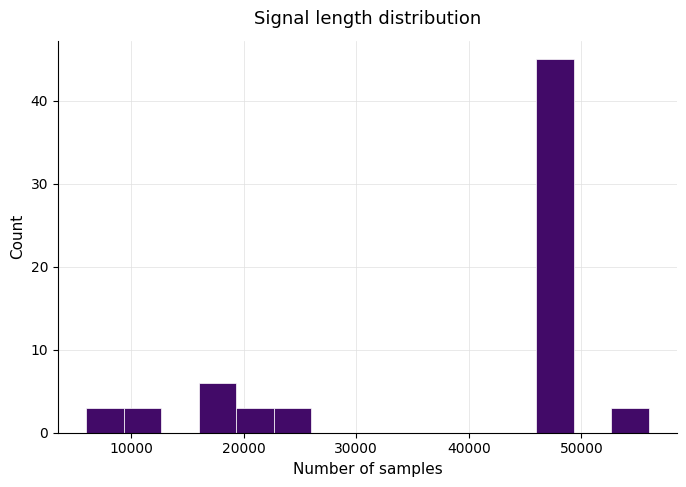

In [4]:
# Signal length distribution
signal_lengths = df_acc.groupby('file')['sample'].max() + 1

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(signal_lengths, bins=15, color=colors[0], edgecolor='white', linewidth=0.5)
ax.set_title('Signal length distribution')
ax.set_xlabel('Number of samples')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../figures/signal_length_distribution.pdf', bbox_inches='tight')
plt.show()

## 3.2 Example signal per component

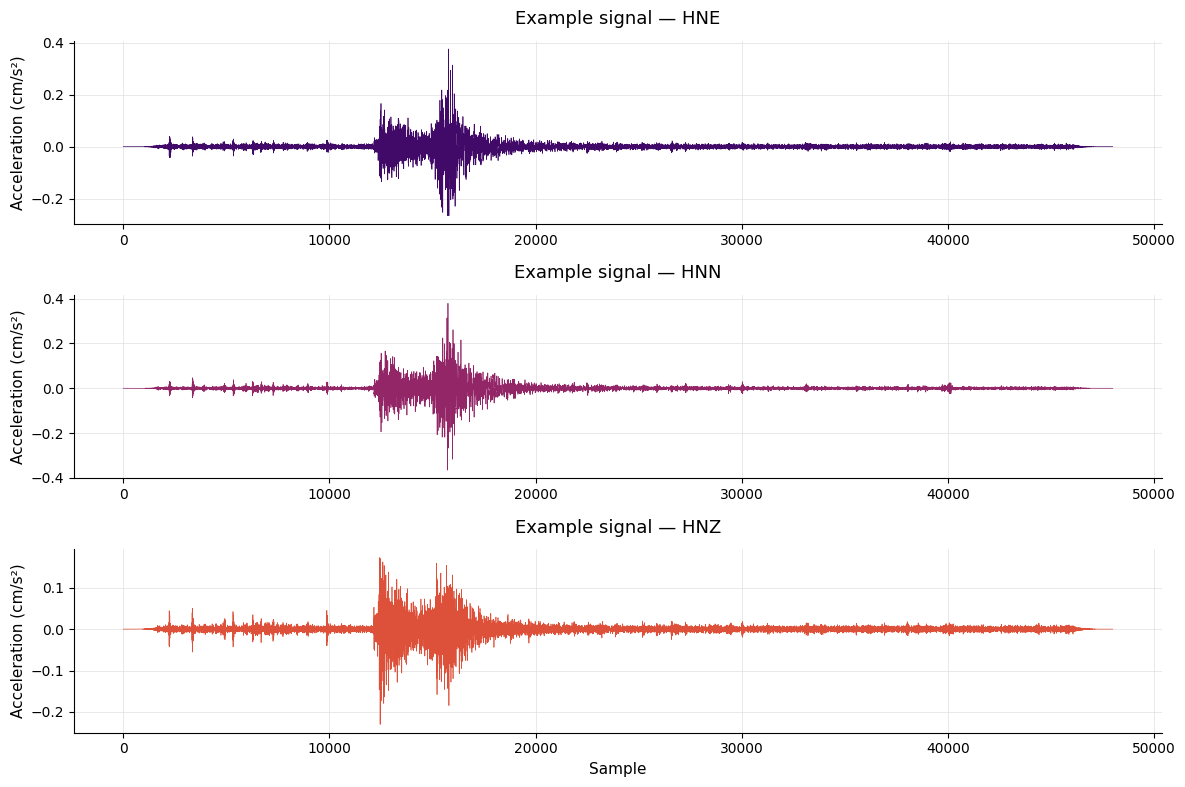

In [5]:
# Display example signals for each stream
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

for i, stream in enumerate(['HNE', 'HNN', 'HNZ']):
    example_file = df_meta_clean[df_meta_clean['STREAM'] == stream]['file'].iloc[0]
    signal = df_acc[df_acc['file'] == example_file]
    axes[i].plot(signal['sample'], signal['acceleration'],
                 color=colors[i], linewidth=0.5)
    axes[i].set_title(f'Example signal — {stream}')
    axes[i].set_ylabel('Acceleration (cm/s²)')

axes[2].set_xlabel('Sample')
plt.tight_layout()
plt.savefig('../figures/example_signals.pdf', bbox_inches='tight')
plt.show()

## 3.3 Global acceleration distribution and acceleration distribution by component (log scale)

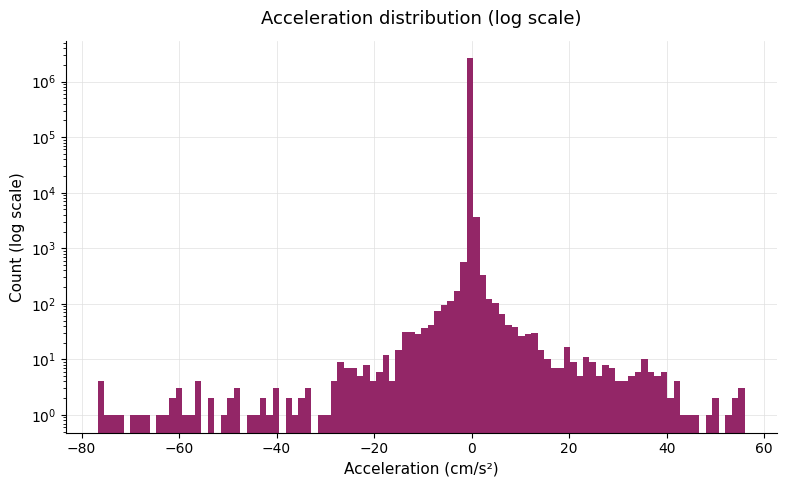

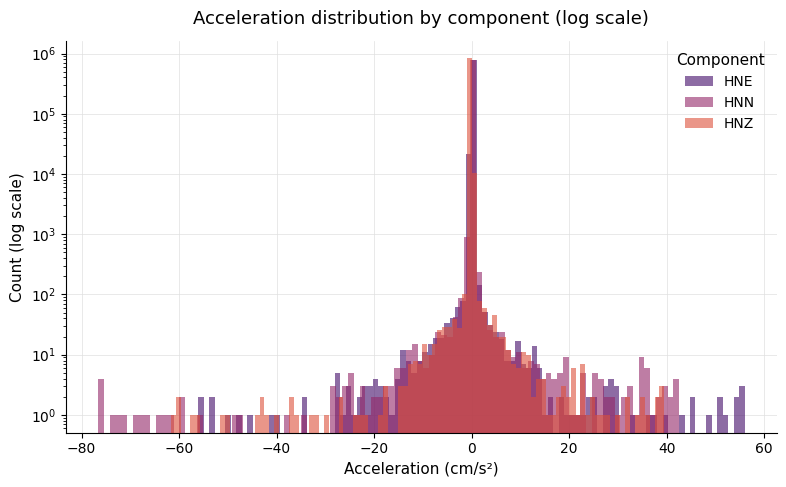

In [6]:
# Global acceleration distribution (log scale)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_acc['acceleration'], bins=100, color=colors[1], edgecolor='none')
ax.set_yscale('log')
ax.set_title('Acceleration distribution (log scale)')
ax.set_xlabel('Acceleration (cm/s²)')
ax.set_ylabel('Count (log scale)')
plt.tight_layout()
plt.savefig('../figures/acceleration_distribution.pdf', bbox_inches='tight')
plt.show()

# Acceleration distribution by component (log scale)
fig, ax = plt.subplots(figsize=(8, 5))
for i, stream in enumerate(['HNE', 'HNN', 'HNZ']):
    files = df_meta_clean[df_meta_clean['STREAM'] == stream]['file'].values
    acc_values = df_acc[df_acc['file'].isin(files)]['acceleration'].values
    ax.hist(acc_values, bins=100, color=colors[i], alpha=0.6,
            label=stream, edgecolor='none')
ax.set_yscale('log')
ax.set_title('Acceleration distribution by component (log scale)')
ax.set_xlabel('Acceleration (cm/s²)')
ax.set_ylabel('Count (log scale)')
ax.legend(title='Component')
plt.tight_layout()
plt.savefig('../figures/acceleration_by_component.pdf', bbox_inches='tight')
plt.show()

In [7]:
# Examine extreme values
print(df_acc[df_acc['acceleration'] < -40]['file'].unique())

['FR.SURF.00.HNE.D.INT-41004391.ACC.MP.ASC'
 'FR.SURF.00.HNN.D.INT-41004391.ACC.MP.ASC'
 'FR.SURF.00.HNZ.D.INT-41004391.ACC.MP.ASC']


# 4. Single signals preprocessing

In [8]:
# Preprocess single signals
df_acc_clean = preprocess_signals_single(df_acc)
print(df_acc_clean.shape)
print(df_acc_clean.head())
print(df_acc_clean[['acceleration', 'acceleration_normalized']].describe())

(2614815, 4)
                                       file  sample  acceleration  \
0  FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC       0 -6.666667e-10   
1  FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC       1 -6.666667e-10   
2  FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC       2 -6.666667e-10   
3  FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC       3 -6.666667e-10   
4  FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC       4 -6.666667e-10   

   acceleration_normalized  
0            -3.401661e-08  
1            -3.401661e-08  
2            -3.401661e-08  
3            -3.401661e-08  
4            -3.401661e-08  
       acceleration  acceleration_normalized
count  2.614815e+06             2.614815e+06
mean   4.731320e-20             6.854573e-19
std    3.865810e-01             9.999876e-01
min   -7.663142e+01            -3.300176e+01
25%   -9.249986e-04            -5.137990e-02
50%   -5.000000e-10            -2.139984e-08
75%    9.219988e-04             5.086609e-02
max    5.600939e+01             3.3180

# 5. Single signal post-preprocessing check and saving

In [9]:
# 1. Baseline check — mean per file should be ~0
baseline_check = df_acc_clean.groupby('file')['acceleration'].mean()
print("Max residual mean:", baseline_check.abs().max())
print("Any mean > 1e-10?", (baseline_check.abs() > 1e-10).any())

# 2. Normalization check — std per file should be ~1
norm_check = df_acc_clean.groupby('file')['acceleration_normalized'].std()
print("\nMean std:", norm_check.mean())
print("Any std far from 1?", ((norm_check - 1).abs() > 1e-6).any())

# 3. No NaN or inf
print("\nNaN in acceleration:", df_acc_clean['acceleration'].isna().sum())
print("NaN in acceleration_normalized:", df_acc_clean['acceleration_normalized'].isna().sum())
print("Inf in acceleration:", np.isinf(df_acc_clean['acceleration']).sum())
print("Inf in acceleration_normalized:", np.isinf(df_acc_clean['acceleration_normalized']).sum())

# 4. Shape unchanged
print("\nShape:", df_acc_clean.shape)
print("N files:", df_acc_clean['file'].nunique())

Max residual mean: 1.9072905147604626e-17
Any mean > 1e-10? False

Mean std: 1.0
Any std far from 1? False

NaN in acceleration: 0
NaN in acceleration_normalized: 0
Inf in acceleration: 0
Inf in acceleration_normalized: 0

Shape: (2614815, 4)
N files: 66


In [10]:
# Save preprocessed data to parquet for later use
try:
    df_acc_clean.to_parquet('../data/processed/acc_preprocessed_single.parquet', index=False)
    print("Saved successfully!")
except Exception as e:
    print(f"Error saving file: {e}")

Saved successfully!


 # 6. Aggregated signals preprocessing

In [11]:
signal_lengths = df_acc.groupby('file')['sample'].max() + 1
pd.set_option('display.max_rows', None)
print(signal_lengths.sort_values())
pd.reset_option('display.max_rows')

file
FR.SURF.00.HNE.D.INT-41004391.ACC.MP.ASC     6000
FR.SURF.00.HNZ.D.INT-41004391.ACC.MP.ASC     6000
FR.SURF.00.HNN.D.INT-41004391.ACC.MP.ASC     6000
IT.BRZ..HGE.D.INT-41004391.ACC.MP.ASC       11001
IT.BRZ..HGZ.D.INT-41004391.ACC.MP.ASC       11001
IT.BRZ..HGN.D.INT-41004391.ACC.MP.ASC       11001
GU.BHB..HNE.D.INT-41004391.ACC.MP.ASC       16601
GU.BHB..HNN.D.INT-41004391.ACC.MP.ASC       16601
GU.BHB..HNZ.D.INT-41004391.ACC.MP.ASC       16601
IT.CRI..HNZ.D.INT-41004391.ACC.MP.ASC       19001
IT.CRI..HNE.D.INT-41004391.ACC.MP.ASC       19001
IT.CRI..HNN.D.INT-41004391.ACC.MP.ASC       19001
IT.SLZ..HNZ.D.INT-41004391.ACC.MP.ASC       20001
IT.SLZ..HNN.D.INT-41004391.ACC.MP.ASC       20001
IT.SLZ..HNE.D.INT-41004391.ACC.MP.ASC       20001
IT.SAV..HGE.D.INT-41004391.ACC.MP.ASC       23001
IT.SAV..HGN.D.INT-41004391.ACC.MP.ASC       23001
IT.SAV..HGZ.D.INT-41004391.ACC.MP.ASC       23001
FR.SAOF.00.HNN.D.INT-41004391.ACC.MP.ASC    48000
FR.REVF.00.HN2.D.INT-41004391.ACC.MP.ASC    4

In [12]:
# Preprocess aggregated signals
df_acc_agg = preprocess_signals_aggregated(df_acc)
print(df_acc_agg.shape)
print(df_acc_agg.head())
print(df_acc_agg[['acceleration', 'acceleration_normalized']].describe())

(2304000, 4)
                                       file  sample  acceleration  \
0  FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC       0 -6.666667e-10   
1  FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC       1 -6.666667e-10   
2  FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC       2 -6.666667e-10   
3  FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC       3 -6.666667e-10   
4  FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC       4 -6.666667e-10   

   acceleration_normalized  
0            -3.401661e-08  
1            -3.401661e-08  
2            -3.401661e-08  
3            -3.401661e-08  
4            -3.401661e-08  
       acceleration  acceleration_normalized
count  2.304000e+06             2.304000e+06
mean   1.969257e-20             9.777817e-19
std    2.003039e-02             9.999898e-01
min   -9.768020e-01            -3.300176e+01
25%   -8.370005e-04            -5.105954e-02
50%   -3.125000e-10            -2.277275e-08
75%    8.350030e-04             5.059843e-02
max    7.343670e-01             3.3180

# 7. Aggregated signals post-preprocessing check and saving

In [13]:
# 1. Truncation check — only files with >= 48000 samples
signal_lengths_agg = df_acc_agg.groupby('file')['sample'].max() + 1
print("N files after truncation:", df_acc_agg['file'].nunique())
print("Signal lengths:\n", signal_lengths_agg.value_counts())

# 2. Baseline check — mean per file should be ~0
baseline_check = df_acc_agg.groupby('file')['acceleration'].mean()
print("\nMax residual mean:", baseline_check.abs().max())
print("Any mean > 1e-10?", (baseline_check.abs() > 1e-10).any())

# 3. Normalization check — std per file should be ~1
norm_check = df_acc_agg.groupby('file')['acceleration_normalized'].std()
print("\nMean std:", norm_check.mean())
print("Any std far from 1?", ((norm_check - 1).abs() > 1e-6).any())

# 4. No NaN or inf
print("\nNaN in acceleration:", df_acc_agg['acceleration'].isna().sum())
print("NaN in acceleration_normalized:", df_acc_agg['acceleration_normalized'].isna().sum())
print("Inf in acceleration:", np.isinf(df_acc_agg['acceleration']).sum())
print("Inf in acceleration_normalized:", np.isinf(df_acc_agg['acceleration_normalized']).sum())

# 5. Shape
print("\nShape:", df_acc_agg.shape)

N files after truncation: 48
Signal lengths:
 sample
48000    48
Name: count, dtype: int64

Max residual mean: 1.3452633737155947e-19
Any mean > 1e-10? False

Mean std: 1.0000000000000002
Any std far from 1? False

NaN in acceleration: 0
NaN in acceleration_normalized: 0
Inf in acceleration: 0
Inf in acceleration_normalized: 0

Shape: (2304000, 4)


In [15]:
# Save preprocessed data to parquet for later use
try:
    df_acc_agg.to_parquet('../data/processed/acc_preprocessed_aggregated.parquet', index=False)
    print("Saved successfully!")
except Exception as e:
    print(f"Error saving file: {e}")

Saved successfully!
